# 1. Your first SWAN model

**What this shows:** the smallest complete SWAN setup built with rompy-swan: swell
arriving at the coast off Perth, from bathymetry data to a model run and a map of the
results.

**Prerequisites:** none. This is the start of the [tutorial](../README.md). If you are
new to rompy, [What rompy does](../../../docs/why-rompy.md) gives the big picture first.

**You will learn:**

- how rompy and rompy-swan split the work between *what* the model is and *when and
  where* it runs
- how a grid, bathymetry, a wave boundary and physics come together in a `SwanConfig`
- how `ModelRun` writes a SWAN workspace: the command file `INPUT` plus input files
- how to run SWAN on that workspace with Docker

**Data used:** `etopo15s_perth.nc`, ETOPO 2022 bathymetry off Perth, Western
Australia, in the [`data/`](../data) folder of this repository.

## How the pieces fit together

[SWAN](https://swanmodel.sourceforge.io/) is a spectral wave model: it computes how
the wave spectrum evolves over a grid, driven by wind, bathymetry and boundary waves.
It reads a command file, `INPUT`, whose commands come in a fixed order. rompy-swan
describes each group of commands with an object, and
[rompy](https://rom-py.github.io/rompy/) adds the run period and generates the files:

```text
ModelRun                  rompy: the run period, the output directory, generates files
└── config: SwanConfig    rompy-swan: the SWAN command file
    ├── startup           PROJECT, SET, MODE, COORDINATES
    ├── cgrid             CGRID: the computational and spectral grids (required)
    ├── inpgrid           INPGRID/READINP: bathymetry, wind and other input grids
    ├── boundary          BOUNDSPEC/BOUNDNEST: waves entering the domain
    ├── physics           GEN3, BREAKING, FRICTION, ...
    ├── output            BLOCK, TABLE, SPECOUT: what SWAN writes
    └── lockup            COMPUTE and STOP
```

Each object checks its own settings, and together they write `INPUT`.

## Setup

The example data ships with this repository. Outputs go to a local `_output` folder
that is safe to delete.

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")  # rompy logs every step, show warnings only

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "01_first_model"
shutil.rmtree(OUT_DIR, ignore_errors=True)

## 1. Run period

`TimeRange` comes from rompy and defines when the model runs. This first model is
stationary: SWAN computes the wave field for a single moment, so start and end are the
same.

In [2]:
from rompy.core.time import TimeRange

period = TimeRange(start="2023-01-01T00:00", end="2023-01-01T00:00", interval="1h")

## 2. Computational grid

A `SwanGrid` describes a regular grid by its lower-left corner, spacing and number of
points. This one covers the coast from Rottnest Island to Mandurah at 0.02° (about
2 km). The computational grid, `CGRID`, adds the spectral grid: 36 directions and
frequencies from 0.04 to 1 Hz. [Tutorial 2](02_grid_and_spectrum.ipynb) explains both.

In [3]:
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.grid import SwanGrid
from rompy_swan.subcomponents.spectrum import SPECTRUM

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
cgrid = REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0))
print(cgrid.render())

CGRID REGULAR xpc=114.5 ypc=-32.8 alpc=0.0 xlenc=1.4 ylenc=1.3 mxc=70 myc=65 CIRCLE mdc=36 flow=0.04 fhigh=1.0


## 3. Bathymetry

A `SwanDataGrid` turns a dataset into a SWAN input grid. Here it reads the elevation
`z` from the ETOPO file. SWAN expects depths positive down, so `fac=-1` flips the sign.
The data is cropped to the grid, with a small buffer.

In [4]:
from rompy.core.source import SourceFile
from rompy_swan.data import SwanDataGrid
from rompy_swan.interface import DataInterface

bottom = SwanDataGrid(
    var="bottom",
    source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
    z1="z",
    fac=-1.0,
    coords={"x": "longitude", "y": "latitude"},
    buffer=0.1,
)
inpgrid = DataInterface(bottom=bottom)

## 4. Wave boundary

Swell enters through the western (offshore) side of the grid. `BOUNDSPEC` applies a
JONSWAP spectrum with a significant wave height of 2 m, a peak period of 12 s, waves
coming from 240° (south-west) and a directional spreading of 20°.
[Tutorial 4](04_wave_boundaries.ipynb) shows how to use spectra from a wave model
instead.

In [5]:
from rompy_swan.components.boundary import BOUNDSPEC
from rompy_swan.subcomponents.boundary import CONSTANTPAR, SIDE
from rompy_swan.subcomponents.spectrum import JONSWAP, SHAPESPEC

boundary = BOUNDSPEC(
    shapespec=SHAPESPEC(shape=JONSWAP(gamma=3.3), per_type="peak", dspr_type="degrees"),
    location=SIDE(side="west", direction="ccw"),
    data=CONSTANTPAR(hs=2.0, per=12.0, dir=240.0, dd=20.0),
)

## 5. Startup, physics, output and computation

- **Startup:** `SET NAUTICAL` makes directions mean *coming from*, clockwise from
  north, and the coordinates are spherical (longitude and latitude).
- **Physics:** `GEN3` is SWAN's third-generation physics. There is no wind in this
  model, so the four-wave (quadruplet) interactions are switched off, as SWAN
  requires.
- **Output:** a `BLOCK` writes maps on the computational grid (`COMPGRID`) to a
  NetCDF file.
- **Lockup:** `COMPUTE` runs the single computation of stationary mode, SWAN's
  default.

In [6]:
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE
from rompy_swan.components.output import BLOCK
from rompy_swan.components.physics import GEN3, OFF, OFFS
from rompy_swan.components.startup import COORDINATES, PROJECT, SET
from rompy_swan.subcomponents.startup import SPHERICAL

startup = STARTUP(
    project=PROJECT(name="First model", nr="t01"),
    set=SET(direction_convention="nautical"),
    coordinates=COORDINATES(kind=SPHERICAL()),
)
physics = PHYSICS(gen=GEN3(), deactivate=OFFS(offs=[OFF(physics="quadrupl")]))
output = OUTPUT(
    block=BLOCK(
        sname="COMPGRID", fname="swangrid.nc", output=["depth", "hsign", "dir", "tps"]
    )
)
lockup = LOCKUP(compute=COMPUTE())

## 6. Assemble the model

`SwanConfig` gathers the pieces. Only `cgrid` is required; everything else is added
as needed.

In [7]:
from rompy_swan.config import SwanConfig

config = SwanConfig(
    startup=startup,
    cgrid=cgrid,
    inpgrid=inpgrid,
    boundary=boundary,
    physics=physics,
    output=output,
    lockup=lockup,
)

## 7. Generate the workspace

`ModelRun` combines the config with the run period and an output directory. Calling
it writes the workspace into `output_dir/run_id`: the bathymetry cropped to the grid
(`bottom.grd`) and the command file `INPUT`.

In [8]:
from rompy.model import ModelRun

modelrun = ModelRun(
    run_id="first_model", period=period, output_dir=OUT_DIR, config=config
)
workspace = Path(modelrun())
sorted(p.name for p in workspace.iterdir())

['INPUT', 'bottom.grd']

Each object above wrote its commands to `INPUT`, in the order SWAN expects. Comment
lines starting with `!` are skipped here.

In [9]:
input_file = (workspace / "INPUT").read_text()
print("\n".join(line for line in input_file.splitlines() if line and line[0] != "!"))

PROJECT name='First model' nr='t01'
SET NAUTICAL
COORDINATES SPHERICAL CCM
CGRID REGULAR xpc=114.5 ypc=-32.8 alpc=0.0 xlenc=1.4 ylenc=1.3 mxc=70 myc=65 CIRCLE mdc=36 flow=0.04 fhigh=1.0
INPGRID BOTTOM REG 114.402083333 -32.8979166667 0.0 383 359 0.00416666666667 0.00416666666667 EXC 99.0
READINP BOTTOM -1.0 'bottom.grd' 3 FREE
BOUND SHAPESPEC JONSWAP gamma=3.3 PEAK DSPR DEGREES
BOUNDSPEC SIDE WEST CCW CONSTANT PAR hs=2.0 per=12.0 dir=240.0 dd=20.0
GEN3 WESTHUYSEN DRAG WU
OFF QUADRUPL
BLOCK sname='COMPGRID' fname='swangrid.nc' &
    DEPTH &
    HSIGN &
    DIR &
    TPS
COMPUTE
STOP


## 8. Run SWAN

SWAN itself is not a Python package. The easiest way to run it is the public Docker
image `ghcr.io/rom-py/swan`, used here through rompy's `DockerConfig` backend. If
Docker is not installed, this step is skipped. With your own SWAN installation, run
`swan.exe` from inside the workspace folder instead.

In [10]:
from rompy.backends import DockerConfig


def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
    ok = modelrun.run(backend, workspace_dir=workspace)
    print("SWAN finished successfully" if ok else "SWAN failed, see PRINT")
else:
    print("Docker is not available, skipping the model run")

SWAN finished successfully


SWAN writes a log of the run to `PRINT`, and the maps to `swangrid.nc`. Here is the
significant wave height, with arrows for the mean direction the waves travel to. The
islands shelter the coast behind them, and the waves turn towards the shore as they
reach shallow water.

The wave height also drops towards the southern edge. Waves are only prescribed on
the western side, and SWAN assumes no waves enter through the others, so a shadow
spreads from the south-west corner. [Tutorial 4](04_wave_boundaries.ipynb) removes
it with boundary spectra on every open side.

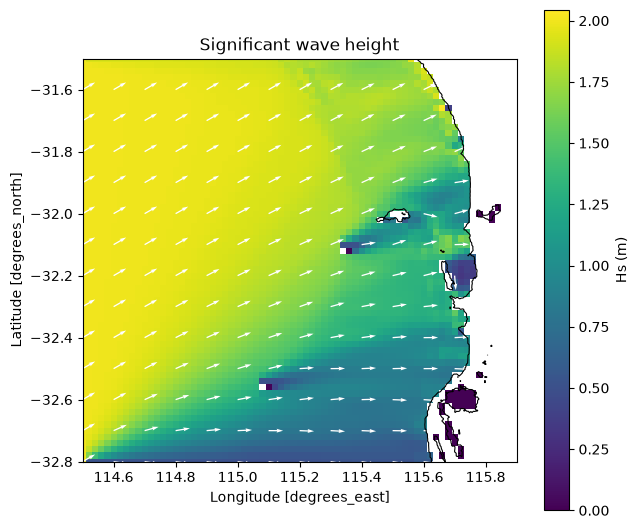

In [11]:
outfile = workspace / "swangrid.nc"
if outfile.exists():
    ds = xr.open_dataset(outfile).isel(run=0)
    etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
    fig, ax = plt.subplots(figsize=(7, 6.5))
    ds.hs.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "Hs (m)"})
    etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.8)
    # Nautical directions are where waves come from, the arrows show where they go
    step = ds.isel(longitude=slice(None, None, 5), latitude=slice(None, None, 5))
    towards = np.deg2rad(step.theta0 + 180)
    ax.quiver(
        step.longitude, step.latitude, np.sin(towards), np.cos(towards),
        color="w", scale=30, width=0.003,
    )
    ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), title="Significant wave height")
    ax.set_aspect("equal")

## Next steps

You now have the whole workflow. The next tutorials look at each part in turn:

- [2. The computational grid and spectrum](02_grid_and_spectrum.ipynb)
- [3. Input grids: bathymetry and wind](03_input_grids.ipynb)
- [4. Wave boundaries](04_wave_boundaries.ipynb)
- [5. Choosing model settings](05_model_settings.ipynb)
- [6. A nonstationary hindcast](06_nonstationary_hindcast.ipynb)
- [7. Configuration as YAML and the rompy CLI](07_yaml_and_cli.ipynb)